# Análise de Dados - E-commerce

Projeto de análise exploratória com foco em vendas por marca.

In [7]:
# Importação das bibliotecas necessárias
import pandas as pd                  # Manipulação de dados
import seaborn as sns               # Visualização de dados
import matplotlib.pyplot as plt     # Controle dos gráficos

# Configuração visual padrão
sns.set(style='whitegrid')

In [8]:
# Carregamento do dataset
df = pd.read_csv('ecommerce_estatistica.csv')

# Visualização inicial
print("Primeiras linhas do dataset:\n")
print(df.head())

Primeiras linhas do dataset:

   Unnamed: 0                                             Título  Nota  \
0           1  Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...   4.5   
1           2  Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...   4.7   
2           3  Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...   4.6   
3           4  Kit 3 Short Jeans Feminino Cintura Alta Barato...   4.4   
4           5  Blusa + Calça Térmica Treino Futebol Criança I...   4.7   

   N_Avaliações  Desconto            Marca         Material  \
0        3034.0      18.0             lupo          algodão   
1        5682.0      20.0            zorba          algodão   
2        1700.0      22.0             mash          algodão   
3         507.0       9.0     menina linda             jean   
4          58.0       5.0  roupa zero grau  termico unissex   

                Gênero        Temporada  \
0            Masculino   outono/inverno   
1            Masculino     não definido   
2            Masc

In [9]:
# 1. ANÁLISE INICIAL DOS DADOS


print("\n=== Informações da tabela ===\n")
df.info()

print("\n=== Descrição da tabela ===\n")
print(df.describe())

print("\n=== Valores nulos ===\n")
print(df.isnull().sum())

print("\n=== Colunas ===\n")
print(df.columns)


=== Informações da tabela ===

<class 'pandas.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           295 non-null    int64  
 1   Título               295 non-null    str    
 2   Nota                 295 non-null    float64
 3   N_Avaliações         295 non-null    float64
 4   Desconto             295 non-null    float64
 5   Marca                295 non-null    str    
 6   Material             295 non-null    str    
 7   Gênero               295 non-null    str    
 8   Temporada            295 non-null    str    
 9   Review1              295 non-null    str    
 10  Review2              295 non-null    str    
 11  Review3              295 non-null    str    
 12  Qtd_Vendidos         295 non-null    str    
 13  Preço                295 non-null    float64
 14  Nota_MinMax          295 non-null    float64
 15  N_Avaliações_MinMax

In [10]:
# 2. DEFINIÇÃO DO FOCO DA ANÁLISE


# Seleção das colunas principais
df_analise = df[['Marca', 'Preço', 'Qtd_Vendidos_Cod']]

print(df_analise.head())

             Marca   Preço  Qtd_Vendidos_Cod
0             lupo  232.89           10000.0
1            zorba  199.90           50000.0
2             mash  229.39           10000.0
3     menina linda  129.20            1000.0
4  roupa zero grau   78.03             100.0


In [11]:
# 3. ANÁLISE DE VENDAS POR MARCA


marcas_vendas = df_analise.groupby('Marca')['Qtd_Vendidos_Cod'].sum().sort_values(ascending=False)

top10_marcas = marcas_vendas.head(10)

print(top10_marcas)

Marca
zorba             263100.0
lupo              218150.0
mash               53100.0
almix              50000.0
moda llevo         50000.0
zaroc              50000.0
keeper             40350.0
celi               15000.0
stillger jeans     13300.0
moralice           10000.0
Name: Qtd_Vendidos_Cod, dtype: float64


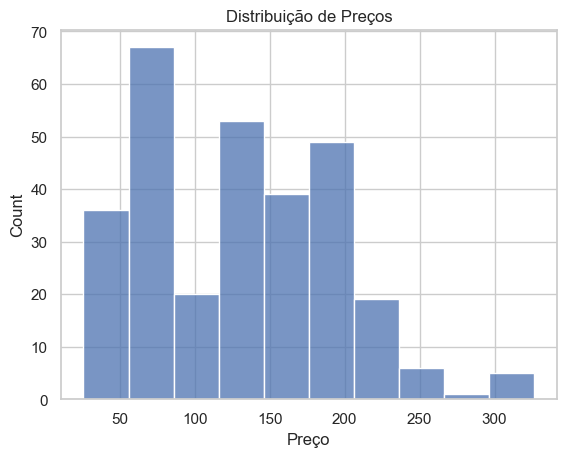

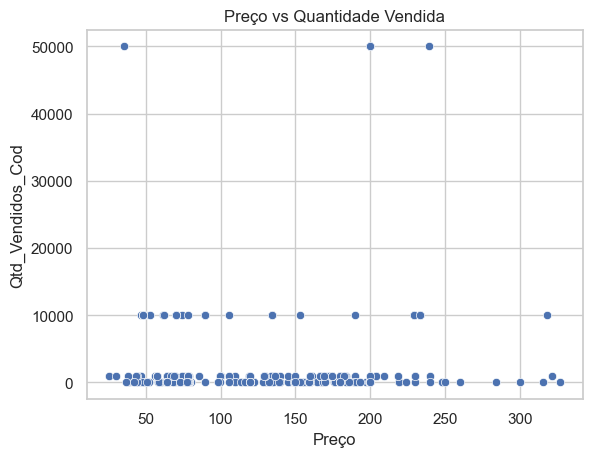

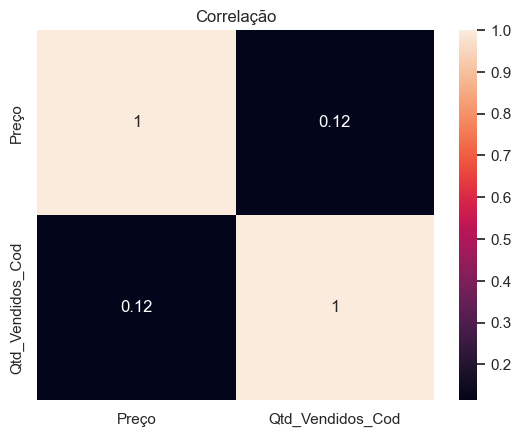

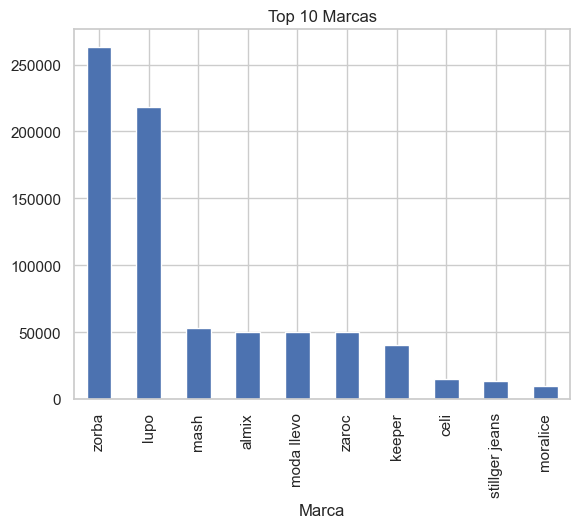

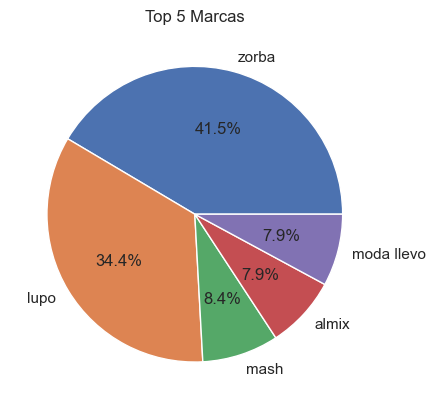

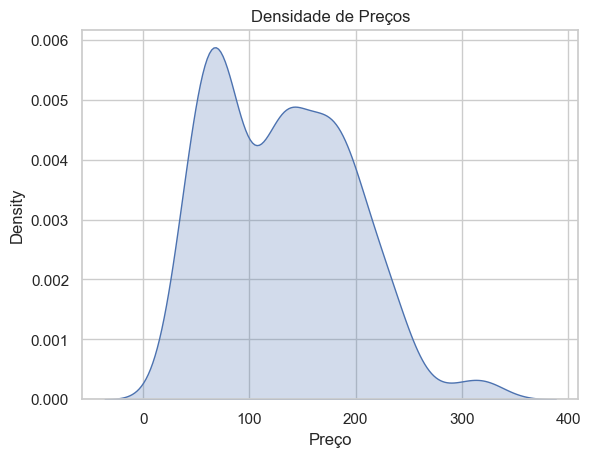

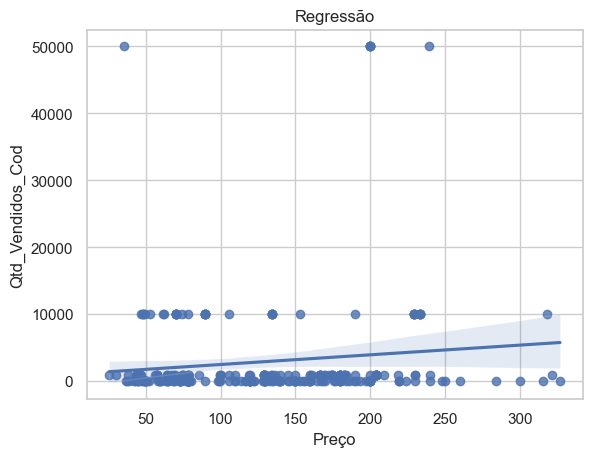

In [12]:
# 4. VISUALIZAÇÕES


# Histograma
plt.figure()
sns.histplot(df_analise['Preço'])
plt.title('Distribuição de Preços')
plt.show()

# Dispersão
plt.figure()
sns.scatterplot(data=df_analise, x='Preço', y='Qtd_Vendidos_Cod')
plt.title('Preço vs Quantidade Vendida')
plt.show()

# Heatmap
plt.figure()
sns.heatmap(df_analise[['Preço','Qtd_Vendidos_Cod']].corr(), annot=True)
plt.title('Correlação')
plt.show()

# Barras
plt.figure()
top10_marcas.plot(kind='bar')
plt.title('Top 10 Marcas')
plt.show()

# Pizza
plt.figure()
top10_marcas.head(5).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 5 Marcas')
plt.ylabel('')
plt.show()

# Densidade
plt.figure()
sns.kdeplot(df_analise['Preço'], fill=True)
plt.title('Densidade de Preços')
plt.show()

# Regressão
plt.figure()
sns.regplot(data=df_analise, x='Preço', y='Qtd_Vendidos_Cod')
plt.title('Regressão')
plt.show()

## Insights

- Algumas marcas concentram maior volume de vendas  
- Existe relação entre preço e quantidade vendida  
- A maioria dos preços está concentrada em certas faixas  
